In [1]:
import numpy as np
import pandas as pd
import scipy
import time
import torch
import sys
sys.path.append('../sourcing_models/')
import matplotlib.pyplot as plt
from lib.dual_sourcing import *

from copy import deepcopy
from collections import Counter
from scipy.stats import truncnorm
from matplotlib import rcParams
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Fira',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 245    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, fig_height]
rcParams.update({'figure.figsize': fig_size})

# Load data
We first load the data that was published along with the MSOM article "Data Set: 187 Weeks of Customer Forecasts and Orders for Microprocessors from Intel Corporation".

In [2]:
data = pd.read_csv("msom.2020.0933.csv")
max_weeks = max(data["Week"].to_numpy())
max_weeks = 115
X = np.arange(1,max_weeks+1)

Next, we select the relevant stock keeping units (SKUs) and customer orders.

In [3]:
def select_SKUs(SKUs):
    
    y = []
    for SKU in SKUs:
        
        data_ = data[data["SKU"] == SKU]
        weeks = data_[data_["SKU"] == SKU]["Week"].to_numpy()
        orders = data_[data_["SKU"] == SKU]["Customer Orders"].to_numpy()
        data_["Total Customer Orders"] = data_.groupby(["Week"])['Customer Orders'].transform('sum')
        total_orders = data_["Total Customer Orders"].to_numpy()
        
        weeks_total_orders = sorted(set([(x[0],x[1]) for x in zip(weeks,total_orders)]))
        
        weeks_ = np.array([x[0] for x in weeks_total_orders])
        total_orders_ = np.array([x[1] for x in weeks_total_orders])
        
        y_ = []
        for i in range(len(X)):
            
            if X[i] in weeks_:
                y_.append(total_orders_[X[i] == weeks_][0])
            else:
                y_.append(np.nan)
        
        y.append(np.array(y_))
    
    return np.array(y)

We select third generation SKUs.

In [4]:
#SKUs = ["SKU-A-2", "SKU-B-2", "SKU-C-1", "SKU-C-2", "SKU-F-1", "SKU-F-2", "SKU-H-2", "SKU-I-2", "SKU-J-2", "SKU-K-2", "SKU-L-1", "SKU-L-2", "SKU-M-2", "SKU-O-1", "SKU-O-2", "SKU-Q-2", "SKU-S-2"]
SKUs = ["SKU-A-3", "SKU-B-3", "SKU-C-3", "SKU-E-3", "SKU-H-3", "SKU-I-3", "SKU-J-3", "SKU-N-3", "SKU-S-3", "SKU-T-3"]
y = select_SKUs(SKUs)

/home/lucasb/anaconda3/envs/TCR/lib/python3.6/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


In [5]:
y_impute = np.nan_to_num(y,nan=0)
max_y = np.max(y_impute)

# Model data by Gaussian process

We now determine the means and standard deviations separately for all weeks.

In [6]:
mean_arr = np.array([np.mean(y_impute[:,i]/1e5) for i in range(len(X))])
std_arr = np.array([np.std(y_impute[:,i]/1e5,ddof=1) for i in range(len(X))])

Plot the original data, mean, and 95% confidence interval.

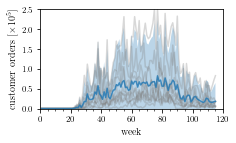

In [7]:
fig, ax = plt.subplots(facecolor='white')
for i in range(len(SKUs)):
    plt.plot(X, y_impute[i]/1e5,alpha=0.3,color='Grey')
plt.plot(X,mean_arr,color='tab:blue',alpha=0.8)
plt.fill_between(X,mean_arr+1.96*std_arr,mean_arr-1.96*std_arr,alpha=0.3)
ax.xaxis.set_minor_locator(MultipleLocator(5))
plt.xlim(0,120)
plt.ylim(0,2.5)
plt.xlabel(r"week")
plt.ylabel(r"customer orders [$\times 10^5$]")
plt.tight_layout()
plt.savefig("gaussian_sampling.png",dpi=480)
plt.show()

Generate samples using a truncated normal distribution.

In [8]:
num_samples = 1000
samples = []
myclip_a = 0
myclip_b = 1e3

for i in range(len(mean_arr)):
    
    my_mean = mean_arr[i]
    my_std = std_arr[i]
    a, b = (myclip_a - my_mean) / (1e-9+my_std), (myclip_b - my_mean) / (1e-9+my_std)
    r = truncnorm.rvs(a, b, loc=my_mean, scale=my_std, size=num_samples)
    samples.append(r)

/home/lucasb/anaconda3/envs/TCR/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: divide by zero encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/lucasb/anaconda3/envs/TCR/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: invalid value encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/lucasb/anaconda3/envs/TCR/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: divide by zero encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/lucasb/anaconda3/envs/TCR/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: invalid value encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/lucasb/anaconda3/envs/TCR/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: divide by zero encountered in true_divide
  x = np.asar

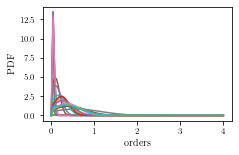

In [9]:
x = np.linspace(0,4,100)
plt.figure()
for i in range(40):
    myclip_a = 0
    myclip_b = 1e2
    my_mean = mean_arr[i]
    my_std = std_arr[i]
    a, b = (myclip_a - my_mean) / (1e-9+my_std), (myclip_b - my_mean) / (1e-9+my_std)
    rv = truncnorm(a, b, loc=my_mean, scale=my_std)
    r = lambda x: rv.pdf(x)
    plt.plot(x,r(x))
plt.xlabel(r"orders")
plt.ylabel(r"PDF")
plt.show()

Compare original data and samples.

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


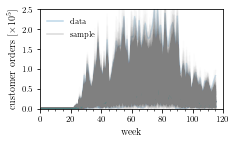

In [10]:
fig, ax = plt.subplots(facecolor="white")
for i in range(len(SKUs)):
    plt.plot(X, y_impute[i]/1e5,alpha=0.2,color="tab:blue")
plt.plot(X,samples,alpha=0.02,color="Grey")
plt.plot(100, 100,alpha=0.3,color="tab:blue",label="data")
plt.plot(100,100,alpha=0.3,color="Grey",label="sample")
ax.xaxis.set_minor_locator(MultipleLocator(5))
plt.xlim(0,120)
plt.ylim(0,2.5)
plt.xlabel(r"week")
plt.ylabel(r"customer orders [$\times 10^5$]")
plt.legend(loc=2,frameon=False,fontsize=8)
plt.tight_layout()
plt.savefig("gaussian_sampling_2.png",dpi=480)
plt.show()

# Apply CDI policy to empirical demand data

In [11]:
#np.random.seed(10)

ce = 20
cr = 0
le = 0
lr = 2
h = 5
b = 495

l = lr-le

In [12]:
myclip_a = 0
myclip_b = 1e3
mean_arr = mean_arr
std_arr = std_arr
max_weeks = len(mean_arr)

#mean_arr = np.append(mean_arr,mean_arr)
#std_arr = np.append(std_arr,std_arr)
#max_weeks = 2*max_weeks

sampling_function = lambda i, num_samples: 1e5*truncnorm.rvs((myclip_a - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         (myclip_b - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         loc=mean_arr[i], scale=std_arr[i], 
                                                         size=num_samples)

quantile_function_0025 = lambda i: truncnorm.ppf(0.025, (myclip_a - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         (myclip_b - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         loc=mean_arr[i], scale=std_arr[i])
quantile_function_0975 = lambda i: truncnorm.ppf(0.975, (myclip_a - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         (myclip_b - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         loc=mean_arr[i], scale=std_arr[i])

In [13]:
def optimal_u1_func(h,
                    b,
                    D_low,
                    D_high):

    return (h*D_low+b*D_high)/(h+b)

def optimal_u2_func(h,
                    b,
                    D_low,
                    D_high,
                    L):
    
    return (h*D_low*L+b*D_high*L)/(h+b)

In [14]:
# determine optimal CDI parameters                             
optimal_u1_old = [int(optimal_u1_func(h, b, \
             max(0,1e5*mean_arr[i]-2.58*1e5*std_arr[i]), \
             1e5*mean_arr[i]+2.58*1e5*std_arr[i])) \
             for i in range(len(mean_arr))]
optimal_u2_old = [int(optimal_u2_func(h, b, \
             max(0,1e5*mean_arr[i]-2.58*1e5*std_arr[i]), \
             1e5*mean_arr[i]+2.58*1e5*std_arr[i], lr-le)) \
             for i in range(len(mean_arr))]
optimal_u3_old = optimal_u1_old

In [15]:
# determine optimal CDI parameters                             
optimal_u1 = [(h*max(0,1e5*mean_arr[i]-2.58*1e5*std_arr[i])+b*( \
             1e5*mean_arr[i]+2.58*1e5*std_arr[i]))/(h+b) \
             for i in range(len(mean_arr))]

optimal_u2 = [(h*sum([max(0,1e5*mean_arr[i+j]-2.58*1e5*std_arr[i+j]) for j in range(l)]) + b*(\
             sum([1e5*mean_arr[i+j]+2.58*1e5*std_arr[i+j] for j in range(l)])))/(h+b) if i < len(mean_arr)-l else \
             (h*(sum([max(0,1e5*mean_arr[i+j]-2.58*1e5*std_arr[i+j]) for j in range(len(mean_arr)-i)])+\
             (l-len(mean_arr)+i)*max(0,1e5*mean_arr[-1]-2.58*1e5*std_arr[-1])) + b*(\
             sum([1e5*mean_arr[i+j]+2.58*1e5*std_arr[i+j] for j in range(len(mean_arr)-i)])+\
             (l-len(mean_arr)+i)*max(0,1e5*mean_arr[-1]+2.58*1e5*std_arr[-1])))/(h+b)
             for i in range(len(mean_arr))]

optimal_u3 =  [(h*max(0,1e5*mean_arr[i+l]-2.58*1e5*std_arr[i+l])+b*( \
             1e5*mean_arr[i+l]+2.58*1e5*std_arr[i+l]))/(h+b) if i < len(mean_arr)-l else 
             (h*max(0,1e5*mean_arr[-1]-2.58*1e5*std_arr[-1])+b*( \
             1e5*mean_arr[-1]+2.58*1e5*std_arr[-1]))/(h+b) \
             for i in range(len(mean_arr))]

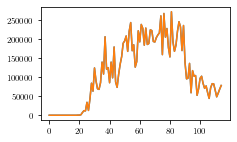

In [16]:
plt.figure()
plt.plot(optimal_u1_old)
plt.plot(optimal_u1)
plt.show()

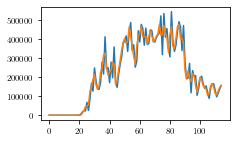

In [17]:
plt.figure()
plt.plot(optimal_u2_old)
plt.plot(optimal_u2)
plt.show()

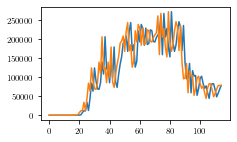

In [18]:
plt.figure()
plt.plot(optimal_u3_old)
plt.plot(optimal_u3)
plt.show()

In [19]:
cost_arr = []
I0 = 0
for i in range(1000):
        S = DualSourcingModel(ce=ce, 
                              cr=cr, 
                              le=le, 
                              lr=lr, 
                              h=h, 
                              b=b,
                              T=max_weeks, 
                              I0=I0,
                              u1=optimal_u1,
                              u2=optimal_u2,
                              u3=optimal_u3,
                              capped_dual_index=True,
                              demand_distribution=[sampling_function])

        S.simulate()
        cost_arr.append(S.total_cost)

In [20]:
print(np.mean(cost_arr)/max_weeks,np.std(cost_arr)/max_weeks)

722394.6878260869 53242.62112012785


# Compare CDI with NNC-based policies

Generate sampling function.

In [21]:
myclip_a = 0
myclip_b = 1e3
mean_arr = mean_arr
std_arr = std_arr
max_weeks = len(mean_arr)

#mean_arr = np.append(mean_arr,mean_arr)
#std_arr = np.append(std_arr,std_arr)
#max_weeks = 2*max_weeks

sampling_function = lambda i, num_samples: 1e5*truncnorm.rvs((myclip_a - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         (myclip_b - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         loc=mean_arr[i], scale=std_arr[i], 
                                                         size=num_samples)

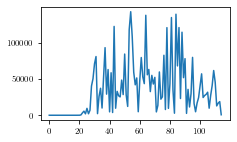

In [22]:
plt.figure()
plt.plot([np.mean(sampling_function(i,1)) for i in range(max_weeks)])
plt.show()

In [304]:
sourcing_parameters = dict(ce=20,
                           cr=0,
                           le=0,
                           lr=2,
                           h=5,
                           b=495,
                           T=max_weeks,
                           demand_distribution=[sampling_function],
                           empirical_baseline=2)    

In [305]:
random_seed = 2131755962840
torch.manual_seed(random_seed)

## NNC Initialization
Here we initialize an NNC model and set  its hyperparameters for training.

In [306]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import torch
from neural_control.controllers import DualFullyConnectedRegressionControllerTime2
from neural_control.dynamics import DualSourcingModel
from copy import deepcopy
from sourcing_models.utilities import sample_trajectories_capped_dual_index_temporal, \
sample_trajectories_dual_index, sample_trajectories_single_index, sample_trajectories_tailored_base_surge

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [307]:
### One can experiment with different layer architectures and activations per layer
nnc_hyperparameters = dict(
    n_hidden_units = [8,8,8]
)

### We use celu non-linearities for the input layer, hidden layers, and output layer
nnc_hyperparameters['n_activations'] = [torch.nn.CELU(alpha=0.1)]*(2 + len(nnc_hyperparameters['n_hidden_units']))


fcc = DualFullyConnectedRegressionControllerTime2(
                                         lr=sourcing_parameters['lr'], 
                                         le=sourcing_parameters['le'], 
                                         n_hidden_units= nnc_hyperparameters ['n_hidden_units'],
                                         activations=nnc_hyperparameters['n_activations']
                                        ) # controller neural network object


## Dynamics Initialization
To further optimize NNC (''fine tuning''), we now apply gradient propagation to the inventory evolution equation:

$I_t = I_{t-1} + q^{\rm e}_{t-l_{\rm e}} + q^{\rm r}_{t-l_{\rm r}} - D_t$

where $I_0, q^{\rm e}_{t},q^{\rm r}_{t}$ are NNC outputs.

In [308]:
dsd = DualSourcingModel(fcc, I_0=4, **sourcing_parameters) # Dual Sourcing Dynamics object

We preserve the best performing model in training, assuming that the neural network generalizes well during training and that our training sample is large enough.

In [232]:
best_loss = [np.infty]
best_model = [None]

In [233]:
all_training_costs = []

In [234]:
optimizer = torch.optim.RMSprop(#[dsd.I_0],
                                list(fcc.parameters()), 
                                lr=2e-4)
                               
optimizer2 = torch.optim.RMSprop([dsd.I_0],
                                #list(fcc.parameters()), 
                                lr=1e-1
                               )

In [235]:
mean_arr_ext = np.append(mean_arr,l*[mean_arr[-1]])
std_arr_ext = np.append(std_arr,l*[std_arr[-1]])

In [116]:
fine_tuning_iterations = 3000
minibatch_size = 1
random_seed = 4

t0 = time.time()
for it in range(fine_tuning_iterations):
    optimizer.zero_grad()
    optimizer2.zero_grad()
    def closure():
        dsd.reset(minibatch_size, seed=random_seed)
        total_costs = 0
        for i in range(dsd.T):
            current_costs, demands, current_inventories, qr, qra, qe, qea = dsd.simulate(\
                                    1e5*mean_arr_ext[i:i+l],1e5*std_arr_ext[i:i+l])
            total_costs = current_costs.mean() + total_costs #1e1*sourcing_parameters["ce"]*int(sum(qea))
        all_training_costs.append(float(total_costs)/dsd.T)
        total_costs.backward()
        if it % 20 == 0:
            print(total_costs/dsd.T)
        if total_costs < best_loss[0]:
            best_loss[0] = total_costs.detach().cpu().item()
            best_model[0] = deepcopy(fcc.state_dict())
        return total_costs
    
    #if best_loss[0]/dsd.T < 8e5:
    #    break
    if it % 10 > 6:
        optimizer2.step(closure)
    else:
        optimizer.step(closure)
t1 = time.time()
total = t1-t0
print(total)

tensor(1.5133e+08, grad_fn=<DivBackward0>)
tensor(1.4197e+08, grad_fn=<DivBackward0>)
tensor(1.3598e+08, grad_fn=<DivBackward0>)
tensor(1.3040e+08, grad_fn=<DivBackward0>)
tensor(1.2461e+08, grad_fn=<DivBackward0>)
tensor(1.1830e+08, grad_fn=<DivBackward0>)
tensor(1.1102e+08, grad_fn=<DivBackward0>)
tensor(1.0345e+08, grad_fn=<DivBackward0>)
tensor(96155408., grad_fn=<DivBackward0>)
tensor(89129008., grad_fn=<DivBackward0>)
tensor(82263808., grad_fn=<DivBackward0>)
tensor(75727432., grad_fn=<DivBackward0>)
tensor(69591368., grad_fn=<DivBackward0>)
tensor(63796940., grad_fn=<DivBackward0>)
tensor(58233440., grad_fn=<DivBackward0>)
tensor(52789524., grad_fn=<DivBackward0>)
tensor(47384728., grad_fn=<DivBackward0>)
tensor(41727012., grad_fn=<DivBackward0>)
tensor(35603412., grad_fn=<DivBackward0>)
tensor(29614246., grad_fn=<DivBackward0>)
tensor(23448706., grad_fn=<DivBackward0>)
tensor(17180066., grad_fn=<DivBackward0>)
tensor(8751211., grad_fn=<DivBackward0>)
tensor(5181080., grad_fn=<D

KeyboardInterrupt: 

In [236]:
optimizer = torch.optim.RMSprop(#[dsd.I_0],
                                list(fcc.parameters()), 
                                lr=2e-4)
                               
optimizer2 = torch.optim.RMSprop([dsd.I_0],
                                #list(fcc.parameters()), 
                                lr=1e-1
                               )

In [253]:
fine_tuning_iterations = 3000
minibatch_size = 128
random_seed = 4

t0 = time.time()
for it in range(fine_tuning_iterations):
    optimizer.zero_grad()
    optimizer2.zero_grad()
    def closure():
        dsd.reset(minibatch_size, seed=random_seed)
        total_costs = 0
        for i in range(dsd.T):
            current_costs, demands, current_inventories, qr, qra, qe, qea = dsd.simulate(\
                                    1e5*mean_arr_ext[i:i+l],1e5*std_arr_ext[i:i+l])
            total_costs = current_costs.mean() + total_costs #1e1*sourcing_parameters["ce"]*int(sum(qea))
        all_training_costs.append(float(total_costs)/dsd.T)
        total_costs.backward()
        if it % 20 == 0:
            print(total_costs/dsd.T)
        if total_costs < best_loss[0]:
            best_loss[0] = total_costs.detach().cpu().item()
            best_model[0] = deepcopy(fcc.state_dict())
        return total_costs
    
    if best_loss[0]/dsd.T < 5.0e5:
        break    
    if it % 10 > 6:
        optimizer2.step(closure)
    else:
        optimizer.step(closure)
t1 = time.time()
total = t1-t0
print(total)

tensor(645636.6875, grad_fn=<DivBackward0>)
tensor(643560.4375, grad_fn=<DivBackward0>)
tensor(641650.3750, grad_fn=<DivBackward0>)
tensor(639520.3750, grad_fn=<DivBackward0>)
tensor(637700.0625, grad_fn=<DivBackward0>)
tensor(635985.8750, grad_fn=<DivBackward0>)
tensor(634586., grad_fn=<DivBackward0>)
tensor(633068.6875, grad_fn=<DivBackward0>)
tensor(631965.3125, grad_fn=<DivBackward0>)
tensor(631077.4375, grad_fn=<DivBackward0>)


KeyboardInterrupt: 

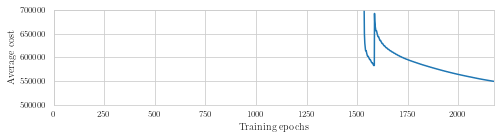

In [120]:
from matplotlib.ticker import NullFormatter

# set nice figure sizes
fig_width_pt = 495    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

costs = np.array(all_training_costs)
#np.savetxt("cost_direct_learning.dat",costs)

fig, ax = plt.subplots(ncols=1)
plt.plot(costs,alpha=1)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel(r'Training epochs')
ax.set_ylabel(r'Average cost')
plt.tight_layout()
#plt.yscale("log")
#plt.xlim(9000,12000)
plt.ylim(5e5,7e5)
plt.margins(0,0)
plt.show()

In [309]:
#fcc.load_state_dict(best_model[0])
best_model_load = torch.load('nnc_best_model_MSOM_081722_baseline2_I0=4_b=495.pt', map_location='cpu')
fcc.load_state_dict(best_model_load)

<All keys matched successfully>

In [122]:
min(costs)

549115.6521739131

In [266]:
#torch.save(best_model[0], 'nnc_best_model_MSOM_081722_baseline2_I0=4_b=495.pt')

In [284]:
dsd.learned_I_0.detach().clone()[0]

ModuleAttributeError: 'DualSourcingModel' object has no attribute 'learned_I_0'

## Comparison 
First, we generate new dual-index samples.
These will be used to compare performance on unseen samples for NNC.

In [310]:
sourcing_parameters = dict(ce=20,
                           cr=0,
                           le=0,
                           lr=2,
                           h=5,
                           b=495,
                           T=max_weeks,
                           I0=4,
                           demand_distribution=[sampling_function],
                           standard_baseline=False)

state_trajectories, qr_trajectories, qe_trajectories =\
    sample_trajectories_capped_dual_index_temporal(n_trajectories=1000, mean_demand_arr=1e5*mean_arr, std_demand_arr=1e5*std_arr, seed=125, **sourcing_parameters)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 321.3316233705828, 321.3316233705828, 1312.9214047392677, 7201.900969984419, 11940.174374235716, 11482.643990634404, 33933.794911292796, 12631.409686409857, 43658.03195473863, 84040.47198726924, 63217.41614943749, 124132.63064426066, 89857.39988513912, 69360.64710688143, 67913.65701553372, 85442.06963269117, 139436.4469667985, 108026.10300839962, 205949.37752663743, 121092.47720243584, 124953.89307736987, 85321.19902799351, 139406.26204537367, 98198.65273892187, 179131.43541320812, 87242.72382347258, 73189.6773594819, 107380.3146492002, 133762.32165364572, 153760.5488365637, 188938.48315474522, 195145.81873300447, 207978.55942091194, 167576.35419951865, 220560.39206549202, 243182.29323306863, 169347.79099789794, 184852.13461167525, 126285.96234947204, 140810.63466751808, 221677.9738324751, 192560.1142910115, 238256.72804639486, 227933.04691904297, 183789.409411036, 228725.2568157064, 185698.

In [311]:
dsd.reset(1)
def evaluate_nnc_on_sample(state_trajectories, 
                           sample_id):
    
    fixed_demands = state_trajectories[sample_id, 1:, 1].unsqueeze(-1)

    nn_inv = dsd.learned_I_0.detach().clone()
    dsd.reset(1)
    nn_qr = [torch.zeros([1,1])]*(dsd.lr+1)
    nn_qe = [torch.zeros([1,1])]*(dsd.le+1)
    nn_ci = []
    all_nn_inv = [nn_inv.item()]
    D = torch.tensor(0.0).unsqueeze(0).unsqueeze(0)
        
    for i in range(sourcing_parameters["T"]):
        mean = 1e5*mean_arr_ext[i:i+l]
        std = 1e5*std_arr_ext[i:i+l]
        min_demands = [max(0,mean[i]-2.58*std[i]) for i in range(len(mean))]
        max_demands = [mean[i]+2.58*std[i] for i in range(len(mean))]
        qr, qe = fcc(D, nn_inv, nn_qr, nn_qe, min_demands, max_demands)
        D = fixed_demands[i].unsqueeze(0)
        nn_qr.append(qr)
        nn_qe.append(qe)
        qra = nn_qr[-dsd.lr-1]
        qea = nn_qe[-dsd.le-1]
        c_i, nn_inv = dsd.replay_step(nn_inv, D, qra, qea, qr, qe)
        nn_ci.append(c_i)
        all_nn_inv.append(nn_inv.item())
    return all_nn_inv, nn_qr, nn_qe, nn_ci, torch.stack(nn_ci).mean()

In [312]:
def evaluate_cdi_on_sample(state_trajectories, 
                           qr_trajectories, 
                           qe_trajectories, 
                           sample_id):
    
    dsd.reset(1)
    fixed_demands = state_trajectories[sample_id, 1:, 1].unsqueeze(-1)

    ds_inv = state_trajectories[sample_id, 0, 0].unsqueeze(0).unsqueeze(0)
    dsd.reset(1)
    all_qr = [0]*dsd.lr
    all_qe = [0]*dsd.le
    all_ci = []
    all_inv = [ds_inv.detach().item()]
    for i in range(sourcing_parameters["T"]):
        D = fixed_demands[i].unsqueeze(0)
        if dsd.le == 0:
            qe = qe_trajectories[sample_id, i+1]
        else:
            qe = qe_trajectories[sample_id, dsd.le+i]
    
        if dsd.lr == 0:
            qr = qr_trajectories[sample_id, i+1]
        else:
            qr = qr_trajectories[sample_id, dsd.lr+i]
            
        all_qr.append(qr)
        all_qe.append(qe)
        qra = all_qr[-dsd.lr-1]
        qea = all_qe[-dsd.le-1]
        #if i == 21:
        #    print(qra, qea, ds_inv, D)
        c_i, ds_inv = dsd.replay_step(ds_inv, D, qra, qea, qr, qe)
        all_inv.append(ds_inv.detach().item())
        all_ci.append(c_i)
    # test if calculated inventories and costs are the same as the ones reported
    # from the dual sourcing code
    assert torch.all(torch.tensor(all_inv) == state_trajectories[sample_id, :, 0])
    assert torch.all(torch.tensor(all_ci) == state_trajectories[sample_id, 1:, -1])
    return all_inv, all_qr, all_qe, all_ci, torch.stack(all_ci).float().mean()

In [315]:
cost_ratios = []
cost_nn = []
cost_cdi = []

samples = 100
for i in range(samples):
    print("%d/%d samples completed"%(i,samples))
    nn_inv, nn_qr, nn_qe, nn_ci, nn_mean_cost = evaluate_nnc_on_sample(state_trajectories, 
                                                                       i)
    
    cdi_inv, cdi_qr, cdi_qe, cdi_ci, cdi_mean_cost = evaluate_cdi_on_sample(state_trajectories, 
                                                                            qr_trajectories, 
                                                                            qe_trajectories, 
                                                                            i)
    cost_nn.append(nn_mean_cost.detach().item())
    cost_cdi.append(cdi_mean_cost.detach().item())
    print("NN cost/CDI cost:", nn_mean_cost.detach().item()/cdi_mean_cost.detach().item())
    cost_ratios.append(nn_mean_cost.detach().item()/cdi_mean_cost.detach().item())

print("mean CDI:", np.mean(cost_cdi))
print("mean NNC:", np.mean(cost_nn))

0/100 samples completed
NN cost/CDI cost: 0.7824097328784028
1/100 samples completed
NN cost/CDI cost: 0.8055418184668407
2/100 samples completed
NN cost/CDI cost: 1.1549854053062183
3/100 samples completed
NN cost/CDI cost: 1.0189481584931257
4/100 samples completed
NN cost/CDI cost: 0.8842021697385328
5/100 samples completed
NN cost/CDI cost: 1.129718687349167
6/100 samples completed
NN cost/CDI cost: 0.761998802321383
7/100 samples completed
NN cost/CDI cost: 0.6920806366838009
8/100 samples completed
NN cost/CDI cost: 1.19089084627774
9/100 samples completed
NN cost/CDI cost: 0.7943503646573455
10/100 samples completed
NN cost/CDI cost: 0.75945369237297
11/100 samples completed
NN cost/CDI cost: 0.7575123277265249
12/100 samples completed
NN cost/CDI cost: 0.9179353932759943
13/100 samples completed
NN cost/CDI cost: 0.7061235857667894
14/100 samples completed
NN cost/CDI cost: 0.7711094120280597
15/100 samples completed
NN cost/CDI cost: 0.9271638019758749
16/100 samples completed

In [316]:
cost_ratios = np.array(cost_ratios)
print(len(cost_ratios[cost_ratios <= 1]))

77


In [317]:
print(np.median(cost_nn),np.median(cost_cdi))
print(np.mean(cost_nn),np.mean(cost_cdi))

619184.375 699778.34375
650562.570625 709124.343125


In [139]:
from scipy.stats import wilcoxon

In [140]:
scipy.stats.wilcoxon(np.array(cost_cdi)-np.array(cost_nn), alternative='greater', mode='approx')

WilcoxonResult(statistic=473315.0, pvalue=5.6106631646900466e-132)

In [ ]:
789522.85625/868222.56

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 469    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

fig, ax = plt.subplots(ncols=2)
#ax[0].text(0.02*(24-22)+22,0.88*1.25,r"(a)")
ax[0].hist(cost_nn,alpha=0.5,bins=50,density=True,label=r"NNC",histtype='step',cumulative=True)
ax[0].hist(cost_cdi,alpha=0.5,bins=50,density=True,label=r"CDI",histtype='step',cumulative=True)
#ax[0].set_xlim(22,24)
ax[0].set_ylim(0,1.25)
ax[0].set_xlabel(r"average cost")
ax[0].set_ylabel(r"CDF")
ax[0].legend(loc=2,fontsize=8,frameon=False)

#ax[1].text(0.02*(1.04-0.96)+0.96,0.88*40,r"(b)")
ax[1].hist(cost_ratios,bins=12,alpha=0.5,density=True)
ax[1].set_xlim(0.5,1)
#ax[1].set_ylim(0,40)
ax[1].set_xlabel(r"cost ratio")

plt.tight_layout()
plt.margins(0,0)
#plt.savefig("cost_comparison_capped_dual_index.png", dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)
plt.show()

## Sample comparison

In [141]:
import plotly.express as px
from plotly import graph_objects as go

In [318]:
fixed_demands = state_trajectories[21, 1:, 1].unsqueeze(-1)
nn_inv, nn_qr, nn_qe, nn_ci, nn_mean_cost = evaluate_nnc_on_sample(state_trajectories, 21)
cdi_inv, cdi_qr, cdi_qe, cdi_ci, cdi_mean_cost = evaluate_cdi_on_sample(state_trajectories, qr_trajectories, qe_trajectories, 21)

In [319]:
a = go.Scatter(y=[x.item() for x in fixed_demands])
fig = go.Figure(a)
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Demand'
fig

In [320]:
a = go.Scatter(y=[x.item() for x in nn_qr[1:]], name='NNC')
b = go.Scatter(y=cdi_qr, name='CDI')
fig = go.Figure([a,b])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Regular Order'
#fig.update_yaxes(range = [0,100])
fig

In [321]:
a = go.Scatter(y=[x.item() for x in nn_qe[1:]], name='NNC')
b = go.Scatter(y=cdi_qe, name='CDI')
fig = go.Figure([a,b])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Expedited Order'
fig

In [322]:
a = go.Scatter(y=[x.item() for x in nn_ci], name='NNC')
b = go.Scatter(y=[x.item() for x in cdi_ci], name='CDI')
fig = go.Figure([a,b])
fig.add_hline(nn_mean_cost.detach().item())
fig.add_hline(cdi_mean_cost.detach().item(),line={'dash':'dash'})
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Cost'
fig

In [ ]:
cdi_mean_cost.detach().item()

In [ ]:
nn_mean_cost.detach().item()

In [ ]:
2.5e6*20/120

In [323]:
a = go.Scatter(y=nn_inv, name='NNC Inventory')
b = go.Scatter(y=cdi_inv, name='CDI Inventory')
c = go.Scatter(y=[x.detach().item() for x in fixed_demands], name='Demand',
               x=torch.arange(1, 1001).tolist() )
fig = go.Figure([a,b, c])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Quantity'
fig

In [ ]:
1+1.7*1.5*20/120

In [ ]:
1.425*1.7

In [ ]:
np.sign(-3)

In [98]:
import matplotlib as mpl

def fix_hist_step_vertical_line_at_end(ax):
    axpolygons = [poly for poly in ax.get_children() if isinstance(poly, mpl.patches.Polygon)]
    for poly in axpolygons:
        poly.set_xy(poly.get_xy()[:-1])

In [324]:
costs_other_model_b495 = np.loadtxt("nnc_best_model_MSOM_081722_baseline2_I0=4_b=495_nn_cdi_costs.csv")
costs_other_model_b95 = np.loadtxt("nnc_best_model_MSOM_081722_baseline2_I0=68_b=95_nn_cdi_costs.csv")

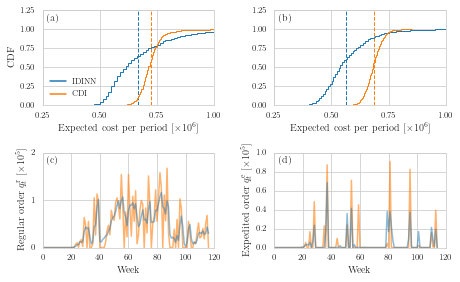

In [328]:
import seaborn as sns
sns.set_style("whitegrid")

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 469.75499  # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, fig_height]
rcParams.update({'figure.figsize': fig_size})

fig, ax = plt.subplots(ncols=2,nrows=2)

CI_0025 = [quantile_function_0025(i) for i in range(max_weeks)]
CI_0975 = [quantile_function_0975(i) for i in range(max_weeks)]

ax[0,0].text(0.02*0.75+0.25,0.88*1.25,r"(a)")
ax[0,0].plot(-10,-10,color=r"tab:blue",label=r"IDINN")
ax[0,0].plot(-10,-10,color=r"tab:orange",label=r"CDI")
ax[0,0].hist(np.array(costs_other_model_b495[:,0])/1e6,alpha=1.0,bins=100,density=True,histtype='step',cumulative=True)
ax[0,0].hist(np.array(costs_other_model_b495[:,1])/1e6,alpha=1.0,bins=100,density=True,histtype='step',cumulative=True)
ax[0,0].vlines(np.mean(costs_other_model_b495[:,0])/1e6,0,1.25,colors="tab:blue",linestyles="--",linewidths=1.0)
ax[0,0].vlines(np.mean(costs_other_model_b495[:,1])/1e6,0,1.25,colors="tab:orange",linestyles="--",linewidths=1.0)
ax[0,0].set_xlim(0.25,1.0)
ax[0,0].set_xticks([0.25,0.5,0.75,1.0])
ax[0,0].set_ylim(0,1.25)
ax[0,0].set_xlabel(r"Expected cost per period [$\times 10^6$]")
ax[0,0].set_ylabel(r"CDF")
ax[0,0].legend(loc=3,fontsize=8,frameon=False)
fix_hist_step_vertical_line_at_end(ax[0,1])

ax[0,1].text(0.02*0.75+0.25,0.88*1.25,r"(b)")
ax[0,1].plot(-10,-10,color=r"tab:blue",label=r"IDINN")
ax[0,1].plot(-10,-10,color=r"tab:orange",label=r"CDI")
ax[0,1].hist(np.array(costs_other_model_b95[:,0])/1e6,alpha=1.0,bins=100,density=True,histtype='step',cumulative=True)
ax[0,1].hist(np.array(costs_other_model_b95[:,1])/1e6,alpha=1.0,bins=100,density=True,histtype='step',cumulative=True)
ax[0,1].vlines(np.mean(costs_other_model_b95[:,0])/1e6,0,1.25,colors="tab:blue",linestyles="--",linewidths=1.0)
ax[0,1].vlines(np.mean(costs_other_model_b95[:,1])/1e6,0,1.25,colors="tab:orange",linestyles="--",linewidths=1.0)
ax[0,1].set_xlim(0.25,1.0)
ax[0,1].set_xticks([0.25,0.5,0.75,1.0])
ax[0,1].set_ylim(0,1.25)
ax[0,1].set_xlabel(r"Expected cost per period [$\times 10^6$]")
#ax[0,1].set_ylabel(r"CDF")
#ax[0,1].legend(loc=4,fontsize=8,frameon=False)
fix_hist_step_vertical_line_at_end(ax[0,1])

a = np.array([x.item() for x in nn_qr[1:]])/1e5
b = np.array(cdi_qr)/1e5
ax[1,0].text(0.02*120,0.88*2,r"(c)")
ax[1,0].plot(b,color=r"tab:orange",label=r"CDI",alpha=0.6)
ax[1,0].plot(a,color=r"tab:blue",label=r"IDINN",alpha=0.5)
ax[1,0].set_xlim(0,120)
ax[1,0].set_ylim(0,2)
ax[1,0].set_yticks([0,1,2])
ax[1,0].set_xlabel(r"Week")
ax[1,0].set_ylabel(r"Regular order $q^{\mathrm{r}}_t$ [$\times 10^5$]")
#ax[0,1].legend(loc=((0.13,0.65)),frameon=False,ncol=1)

a = np.array([x.item() for x in nn_qe[1:]])/1e5
b = np.array(cdi_qe)/1e5
ax[1,1].text(0.02*120,0.88*1,r"(d)")
ax[1,1].plot(b,color=r"tab:orange",alpha=0.6)
ax[1,1].plot(a,color=r"tab:blue",alpha=0.5)#,ls=(0, (1, 2)))
ax[1,1].set_xlim(0,120)
ax[1,1].set_ylim(0,1)
ax[1,1].set_xlabel(r"Week")
ax[1,1].set_ylabel(r"Expedited order $q^{\mathrm{e}}_t$ [$\times 10^5$]")

plt.tight_layout()
plt.margins(0,0)
plt.subplots_adjust(wspace=0.35, hspace=0.5)
plt.savefig("empirical_example_baseline2.png", dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)
plt.show()

In [265]:
#np.savetxt("nnc_best_model_MSOM_081722_baseline2_I0=4_b=495_nn_cdi_costs.csv",np.c_[np.array(cost_nn),np.array(cost_cdi)])